# 03 — Auxetic & Poisson Analysis

Phân tích hệ số Poisson (ν₁₂, ν₂₁) và phát hiện hành vi auxetic (ν < 0) từ dữ liệu tối ưu topology.

**Nguồn dữ liệu:** `data/Shape_Initial_shear/` và `data/Shape_Initial_stiff/` — file `iteration_data.csv`.

**Output figures:** `outputs/figures/auxetic_*.png`

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

# ── config ──
DATA_ROOT = Path('../data')
OUTPUT_DIR = Path('../outputs/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print('Setup OK')

Setup OK


## 1. Load dữ liệu

In [7]:
def load_all_csv(base_dir, label):
    rows = []
    for seed_dir in sorted(base_dir.iterdir()):
        if not seed_dir.is_dir():
            continue
        csv_path = seed_dir / 'iteration_data.csv'
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df['seed'] = seed_dir.name
        df['condition'] = label
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

df_shear = load_all_csv(DATA_ROOT / 'Shape_Initial_shear', 'shear')
df_stiff = load_all_csv(DATA_ROOT / 'Shape_Initial_stiff', 'stiff')
df = pd.concat([df_shear, df_stiff], ignore_index=True)

print(f'Total: {len(df)} rows')
df.head()

Total: 897 rows


,iterations,volume_fractions,poisson_ratios_v12,poisson_ratios_v21,seed,condition
0,1,0.352160,0.336780,0.336780,Cross_regtangular_shear,shear
1,2,0.400000,0.253337,0.253337,Cross_regtangular_shear,shear
2,3,0.399997,0.238307,0.238307,Cross_regtangular_shear,shear
3,4,0.399998,0.202392,0.202392,Cross_regtangular_shear,shear
4,5,0.399998,0.161564,0.161564,Cross_regtangular_shear,shear


## 2. Phân phối Poisson's ratio ν₁₂

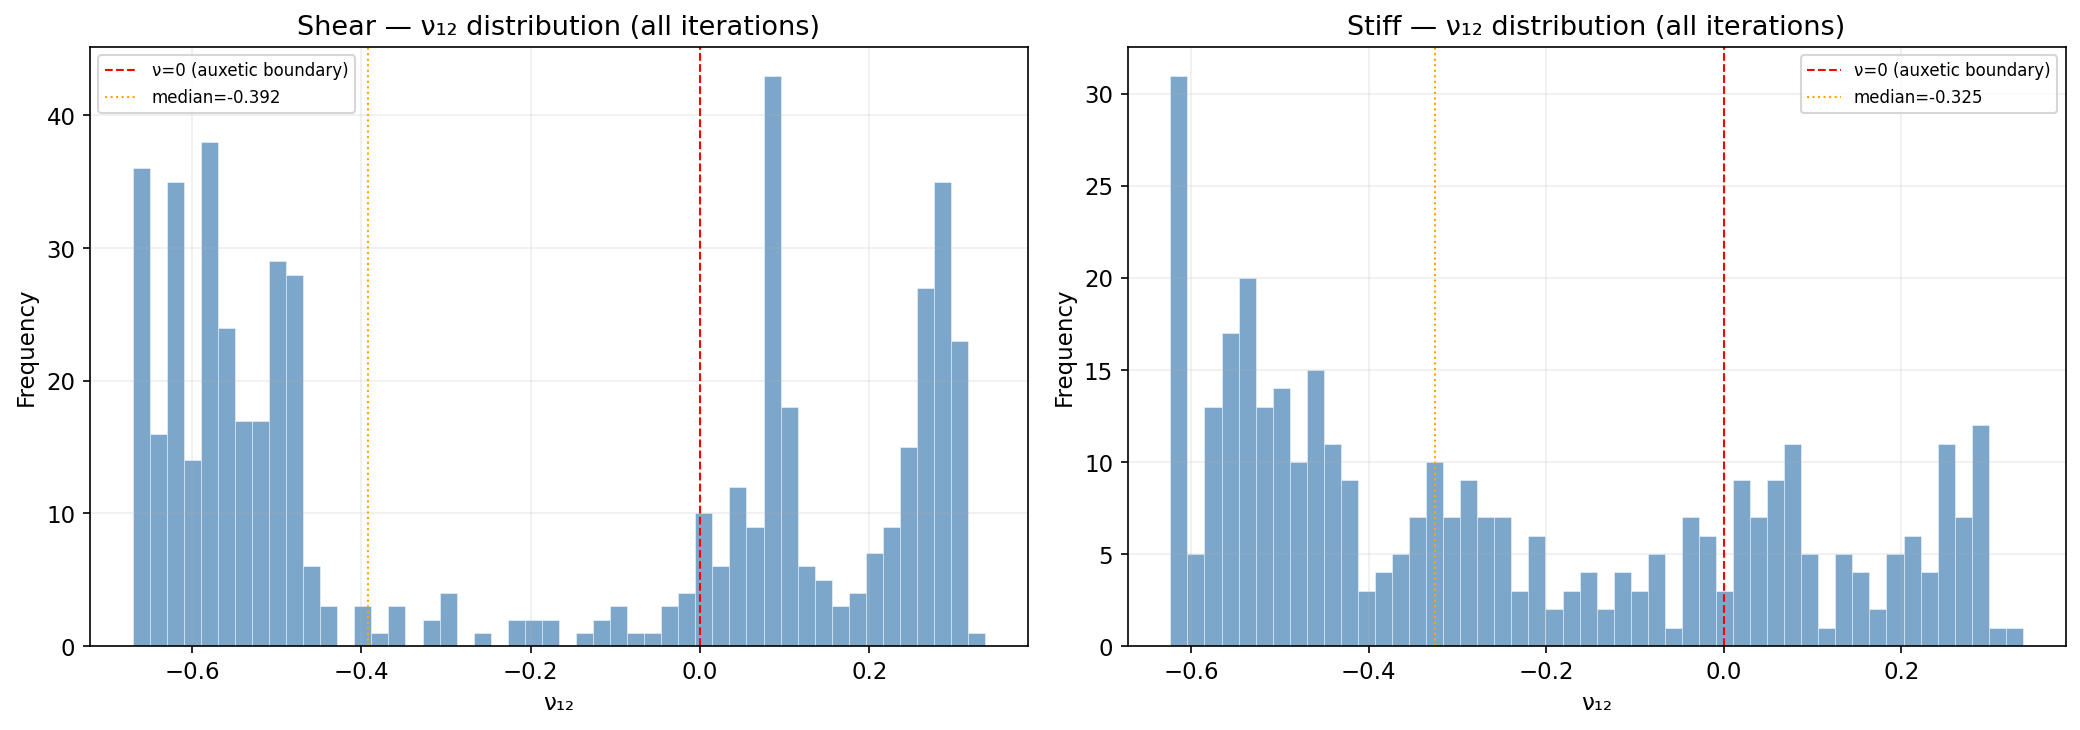

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = df[df['condition'] == cond]['poisson_ratios_v12']
    ax.hist(sub, bins=50, alpha=0.7, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='ν=0 (auxetic boundary)')
    ax.axvline(x=sub.median(), color='orange', linestyle=':', linewidth=1,
               label=f'median={sub.median():.3f}')
    ax.set_title(f'{label} — ν₁₂ distribution (all iterations)')
    ax.set_xlabel('ν₁₂')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auxetic_distribution.png')
plt.show()

## 3. Phát hiện auxetic: ν₁₂ < 0

/tmp/ipykernel_38249/1544038163.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aux_summary = df.groupby(['condition', 'seed']).apply(auxetic_ratio).reset_index()


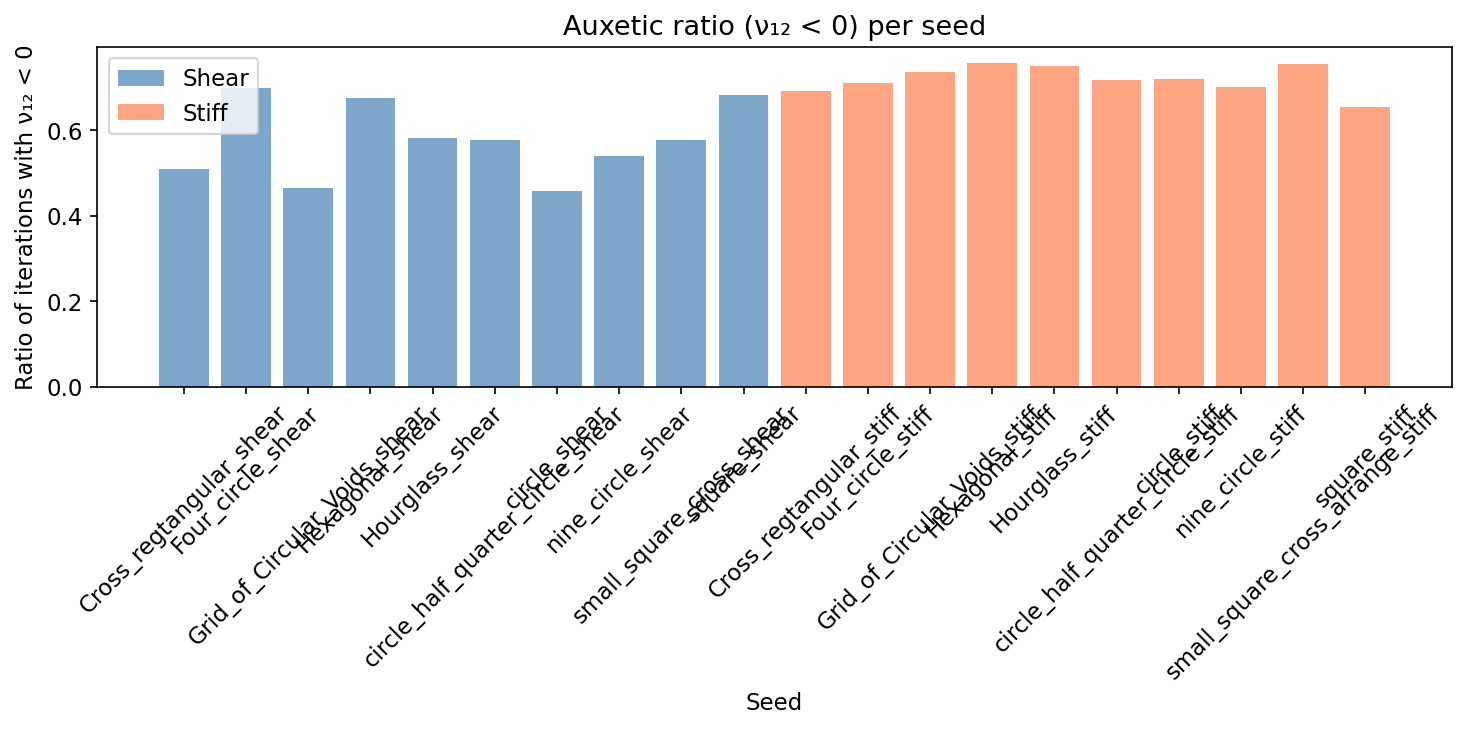


Seeds with highest auxetic ratio (shear):
condition                     seed  auxetic_ratio
    shear        Four_circle_shear       0.698413
    shear             square_shear       0.682927
    shear          Hexagonal_shear       0.675676
    shear          Hourglass_shear       0.581818
    shear small_square_cross_shear       0.576923

Seeds with highest auxetic ratio (stiff):
condition                             seed  auxetic_ratio
    stiff                  Hexagonal_stiff       0.757576
    stiff small_square_cross_arrange_stiff       0.756098
    stiff                  Hourglass_stiff       0.750000
    stiff     Grid_of_Circular_Voids_stiff       0.736842
    stiff                     circle_stiff       0.720930


In [9]:
# Tỉ lệ iteration có ν₁₂ < 0 theo seed
def auxetic_ratio(sub_df):
    total = len(sub_df)
    aux = (sub_df['poisson_ratios_v12'] < 0).sum()
    return aux / total if total > 0 else 0

aux_summary = df.groupby(['condition', 'seed']).apply(auxetic_ratio).reset_index()
aux_summary.columns = ['condition', 'seed', 'auxetic_ratio']

fig, ax = plt.subplots(figsize=(10, 5))
for cond, label, color in [('shear', 'Shear', 'steelblue'), ('stiff', 'Stiff', 'coral')]:
    sub = aux_summary[aux_summary['condition'] == cond].sort_values('seed')
    ax.bar(sub['seed'], sub['auxetic_ratio'], alpha=0.7, label=label, color=color)
ax.set_title('Auxetic ratio (ν₁₂ < 0) per seed')
ax.set_xlabel('Seed')
ax.set_ylabel('Ratio of iterations with ν₁₂ < 0')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auxetic_ratio_per_seed.png')
plt.show()

print('\nSeeds with highest auxetic ratio (shear):')
shear_top = aux_summary[aux_summary['condition']=='shear'].sort_values('auxetic_ratio', ascending=False)
print(shear_top.head(5).to_string(index=False))
print('\nSeeds with highest auxetic ratio (stiff):')
stiff_top = aux_summary[aux_summary['condition']=='stiff'].sort_values('auxetic_ratio', ascending=False)
print(stiff_top.head(5).to_string(index=False))

## 4. Final ν₁₂: best auxetic candidates

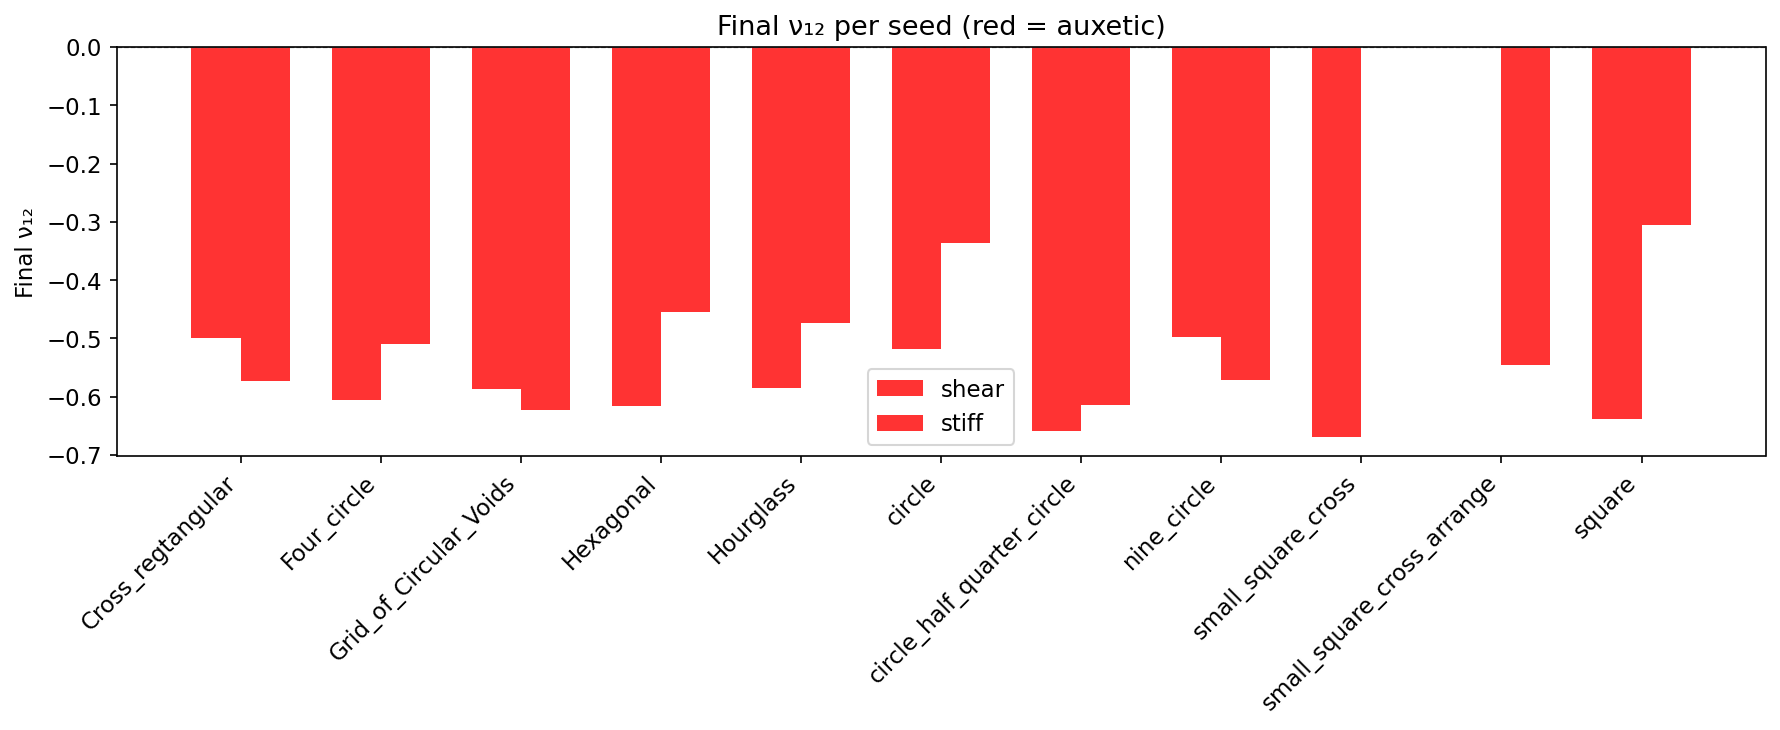


Best auxetic candidates (final ν₁₂ < 0):
                            seed condition  poisson_ratios_v12  volume_fractions
        small_square_cross_shear     shear           -0.668946          0.399900
circle_half_quarter_circle_shear     shear           -0.658159          0.400007
                    square_shear     shear           -0.638296          0.399988
    Grid_of_Circular_Voids_stiff     stiff           -0.622570          0.399988
                 Hexagonal_shear     shear           -0.616515          0.335390
circle_half_quarter_circle_stiff     stiff           -0.614810          0.400023
               Four_circle_shear     shear           -0.606610          0.401000
    Grid_of_Circular_Voids_shear     shear           -0.586121          0.399957
                 Hourglass_shear     shear           -0.585127          0.399999
         Cross_regtangular_stiff     stiff           -0.572573          0.399977
               nine_circle_stiff     stiff           -0.570703     

In [10]:
# Lấy ν₁₂ cuối cùng của mỗi seed
final = df.loc[df.groupby(['condition', 'seed'])['iterations'].idxmax()]
# Tạo base_seed bằng cách loại bỏ hậu tố _shear / _stiff
final['base_seed'] = final['seed'].str.replace('_shear$|_stiff$', '', regex=True)

fig, ax = plt.subplots(figsize=(12, 5))
base_seeds = sorted(final['base_seed'].unique())
x = np.arange(len(base_seeds))
width = 0.35

for i, cond in enumerate(['shear', 'stiff']):
    sub = final[final['condition'] == cond].sort_values('seed')
    # Align to base seeds so missing shapes get 0
    sub_map = sub.set_index('base_seed')['poisson_ratios_v12']
    values = sub_map.reindex(base_seeds).fillna(0)
    # Color: red if auxetic (ν < 0), else steelblue
    bar_colors = ['red' if v < 0 else 'steelblue' for v in values]
    ax.bar(x + i*width, values, width,
           label=cond, alpha=0.8, color=bar_colors)

ax.axhline(y=0, color='grey', linestyle='--', linewidth=0.6)
ax.set_xticks(x + width/2)
ax.set_xticklabels(base_seeds, rotation=45, ha='right')
ax.set_ylabel('Final ν₁₂')
ax.set_title('Final ν₁₂ per seed (red = auxetic)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auxetic_final_v12.png')
plt.show()

# In best auxetic (ν₁₂ < 0)
print('\nBest auxetic candidates (final ν₁₂ < 0):')
aux_final = final[final['poisson_ratios_v12'] < 0].sort_values('poisson_ratios_v12')
print(aux_final[['seed', 'condition', 'poisson_ratios_v12', 'volume_fractions']].to_string(index=False))

## 5. ν₁₂ vs ν₂₁ correlation

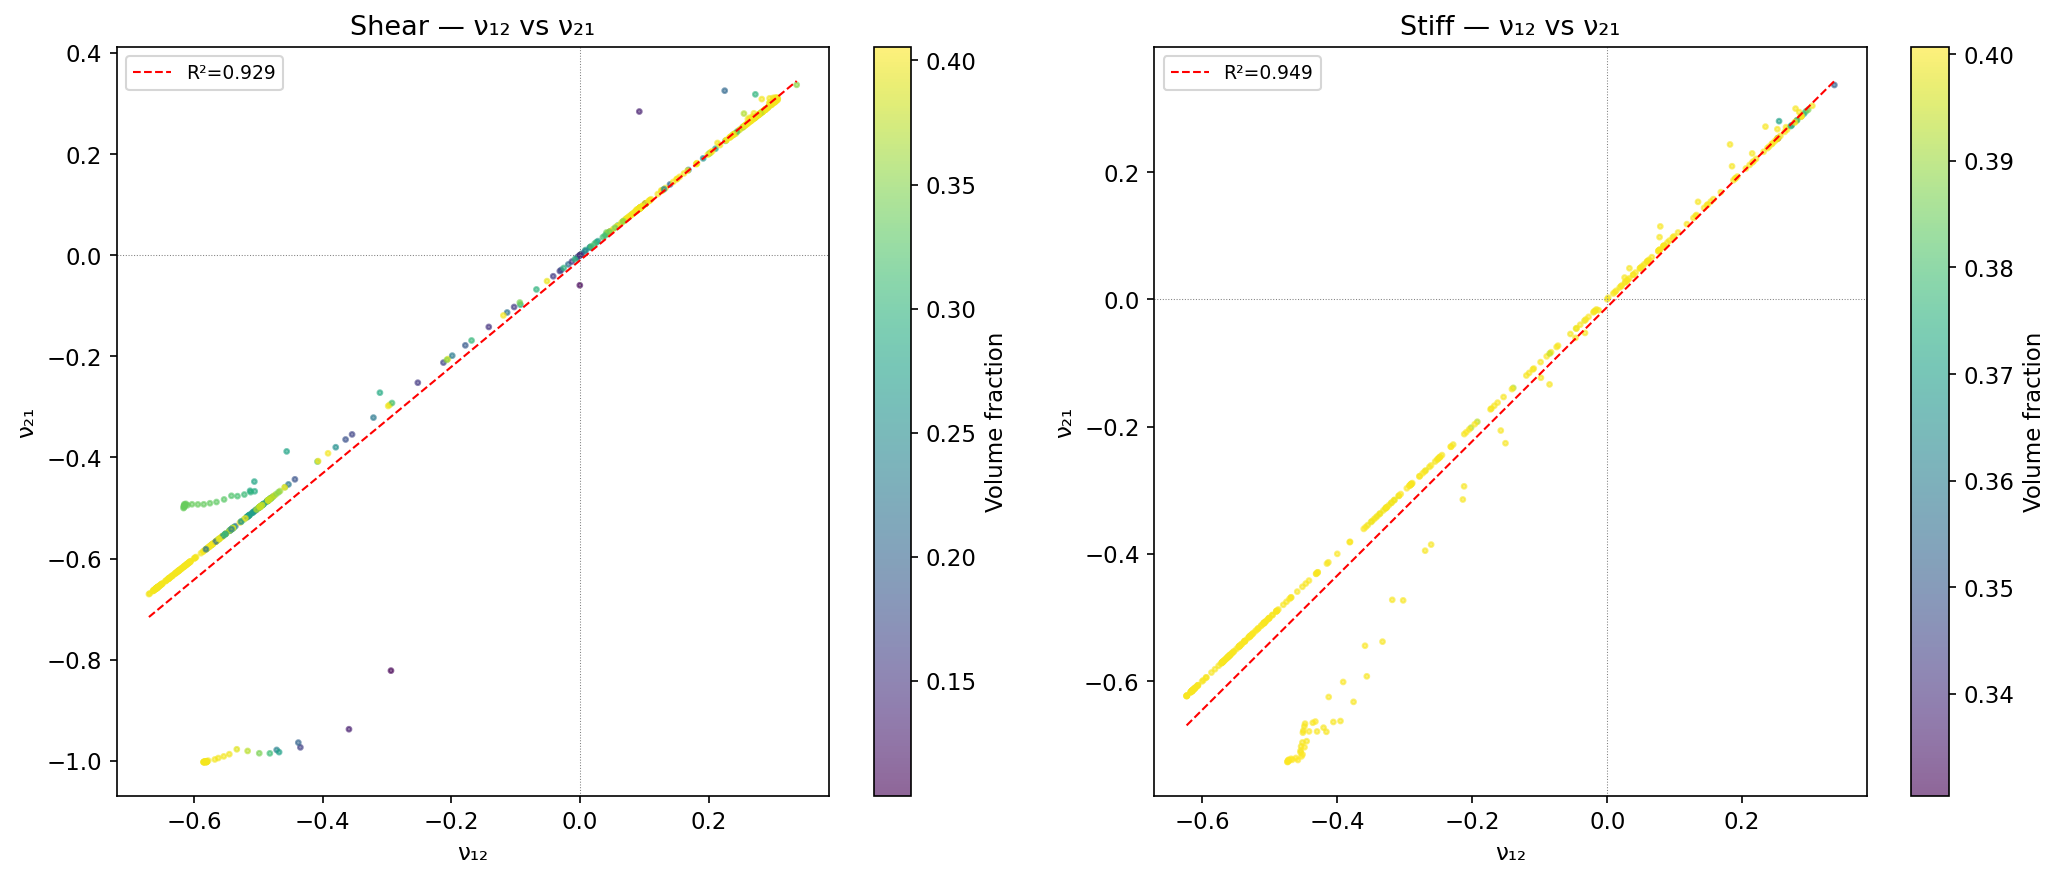

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = df[df['condition'] == cond]
    scatter = ax.scatter(sub['poisson_ratios_v12'], sub['poisson_ratios_v21'],
                         c=sub['volume_fractions'], cmap='viridis', s=5, alpha=0.6)
    ax.axhline(y=0, color='grey', linestyle=':', linewidth=0.5)
    ax.axvline(x=0, color='grey', linestyle=':', linewidth=0.5)
    
    # Regression line
    mask = np.isfinite(sub['poisson_ratios_v12']) & np.isfinite(sub['poisson_ratios_v21'])
    slope, intercept, r_val, p_val, _ = stats.linregress(
        sub['poisson_ratios_v12'][mask], sub['poisson_ratios_v21'][mask])
    x_line = np.linspace(sub['poisson_ratios_v12'].min(), sub['poisson_ratios_v12'].max(), 100)
    ax.plot(x_line, slope*x_line + intercept, 'r--', linewidth=1,
            label=f'R²={r_val**2:.3f}')
    
    ax.set_title(f'{label} — ν₁₂ vs ν₂₁')
    ax.set_xlabel('ν₁₂')
    ax.set_ylabel('ν₂₁')
    ax.legend(fontsize=9)
    plt.colorbar(scatter, ax=ax, label='Volume fraction')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auxetic_v12_vs_v21.png')
plt.show()

## 6. ν₁₂ evolution — chỉ shear seeds có auxetic

Seeds with auxetic final ν₁₂: ['Cross_regtangular_shear', 'Four_circle_shear', 'Grid_of_Circular_Voids_shear', 'Hexagonal_shear', 'Hourglass_shear', 'circle_half_quarter_circle_shear', 'circle_shear', 'nine_circle_shear', 'small_square_cross_shear', 'square_shear', 'Cross_regtangular_stiff', 'Four_circle_stiff', 'Grid_of_Circular_Voids_stiff', 'Hexagonal_stiff', 'Hourglass_stiff', 'circle_half_quarter_circle_stiff', 'circle_stiff', 'nine_circle_stiff', 'small_square_cross_arrange_stiff', 'square_stiff']


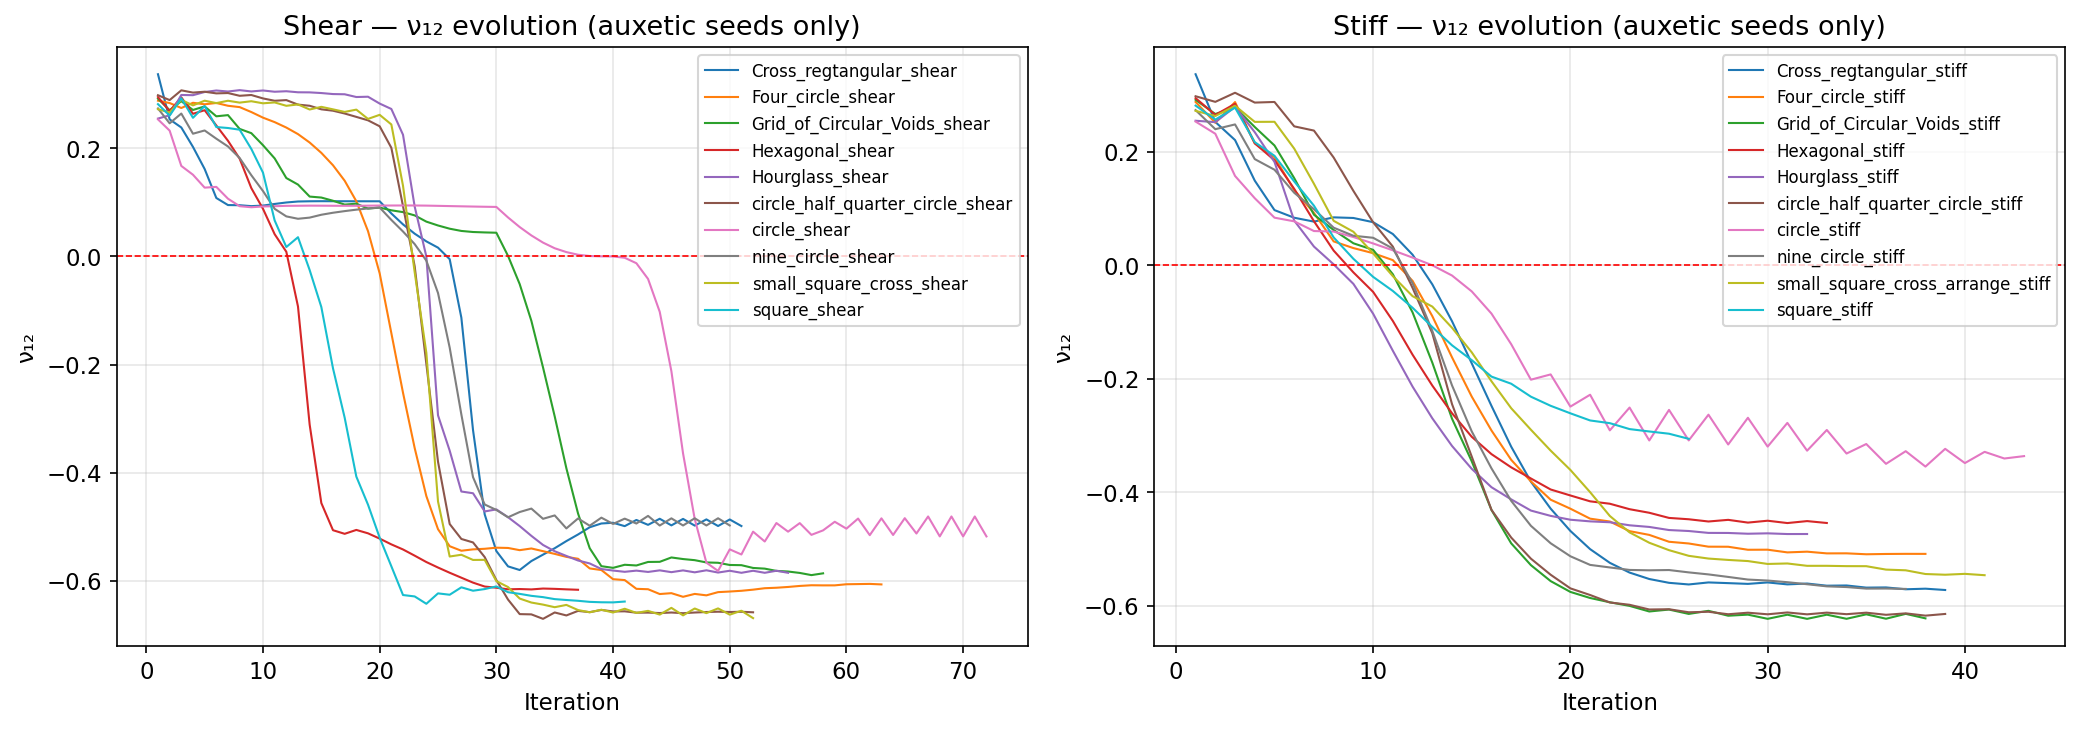

Done — all auxetic figures saved to ../outputs/figures


In [12]:
# Tìm seed nào có final ν₁₂ < 0
aux_seeds = final[final['poisson_ratios_v12'] < 0]['seed'].unique()
print(f'Seeds with auxetic final ν₁₂: {list(aux_seeds)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = df[(df['condition'] == cond) & (df['seed'].isin(aux_seeds))]
    for seed, grp in sub.groupby('seed'):
        grp = grp.sort_values('iterations')
        ax.plot(grp['iterations'], grp['poisson_ratios_v12'],
                label=seed, linewidth=1)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'{label} — ν₁₂ evolution (auxetic seeds only)')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('ν₁₂')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'auxetic_evolution.png')
plt.show()

print('Done — all auxetic figures saved to', OUTPUT_DIR)